# Case study: sc-SVC analysis of fine-grained TAM states in Xenium data

## Notebook Guide

**Purpose.** Preserve and explain the sc-SVC analysis workflow for the Xenium monocyte/macrophage dataset.

**Inputs.** Use either the real-world ST raw data required for reconstruction or the released monocyte/macrophage `spatial.h5ad` / `expr.h5ad` pair described below; the CCI block also consumes the T expression-side object.

### Two ways to obtain the analysis inputs

1. **Reconstruct locally.** Download the [Real-world ST datasets](https://zenodo.org/records/21921802), place `P2CRC_Xenium.h5ad` and `adata_sc_all_reanno.h5ad` under `../../raw_data/Real_application/`, and run `python reconstruct.py --config configs/application/Xenium.yaml --select-ct Mono_Macro` from the repository root.
2. **Start from released results.** Download the [REVISE-reconstructed sc-SVC Xenium data](https://zenodo.org/records/22046001) and place the monocyte/macrophage pair at `../../results/sc_SVC_case/P2CRC_Xenium/Mono_Macro/spatial.h5ad` and `../../results/sc_SVC_case/P2CRC_Xenium/Mono_Macro/expr.h5ad`. Then begin with **Load the reconstructed TAM objects** below.

**Reconstruction input.** The route starts from `../../raw_data/Real_application/P2CRC_Xenium.h5ad` and `../../raw_data/Real_application/adata_sc_all_reanno.h5ad`. The spatial object provides counts and `obsm["spatial"]`; the reference provides shared genes and broad `Level1` labels.

**Reconstruction command.** `python reconstruct.py --config configs/application/Xenium.yaml --select-ct Mono_Macro`

**Expected reconstructed outputs and analysis inputs.** `../../results/sc_SVC_case/P2CRC_Xenium/Mono_Macro/spatial.h5ad` is the spatial-side SVC object in the Xenium panel gene space; `../../results/sc_SVC_case/P2CRC_Xenium/Mono_Macro/expr.h5ad` is the expression-side reference-cell object assigned the same SVC phenotype semantics in a larger gene space. They are **not observation-paired** matrices. The CCI block also reads the T-cell expression-side object as an explicit cross-case analysis input.

**Analysis workflow.** Load and orient TAM clusters; review all reconstructed clusters through marker evidence and spatial localization before selecting focal follow-up; then compare the selected TAM programs on both SVC objects and run CellPhoneDB on four predefined expression-side groups.

**Outputs.** TAM maps, comparison artifacts, local enrichment, CellPhoneDB tables, normalized selected-pair checkpoints, and the LR dot plot are retained under `../../output/P2CRC_Xenium/Mono/`.

**Execution and evidence boundary.** The displayed outputs are accepted execution snapshots. This path-contract update does not establish spatial or causal communication biology.


In [1]:
import os
os.environ.setdefault("TQDM_DISABLE", "1")
os.environ.setdefault("TQDM_MININTERVAL", "60")
import warnings
warnings.filterwarnings("ignore")

try:
    from IPython import get_ipython
    _ipython = get_ipython()
    if _ipython is not None:
        _ipython.run_line_magic("matplotlib", "inline")
except Exception:
    pass

data_root = "../../results/sc_SVC_case/P2CRC_Xenium"
case_dir = f"{data_root}/Mono_Macro"
analysis_output_dir = os.environ.get("REVISE_ANALYSIS_OUTPUT_ROOT", "../../output/P2CRC_Xenium/Mono")
output_dir = analysis_output_dir
os.makedirs(f"{output_dir}/sc_SVC", exist_ok=True)
select_ct = "Mono_Macro"

Matplotlib is building the font cache; this may take a moment.


## Load the reconstructed TAM objects

**Question.** Do the released spatial-side and expression-side objects carry the expected SVC clusters and reference annotations?

**Method.** The notebook initializes the legacy `ScSVCAnalysis` facade used by the published workflow. The following confusion table relates expression-side `SVC_cluster` labels to reference `Level2` labels; it is an annotation summary rather than a reconstruction benchmark.


In [2]:
import scanpy as sc

import sys
sys.path.append("../../")
from revise.backend.runners.sc_svc_application import ScSVCAnalysis
import pandas as pd
import revise.analysis.bio as _revise_bio
from revise.analysis.advanced.enrichment import get_enrichment_local as _strict_get_enrichment_local

_revise_bio.get_enrichment = _strict_get_enrichment_local


sc_svc_expr = sc.read_h5ad(f"{case_dir}/expr.h5ad")
sc_svc_spatial = sc.read_h5ad(f"{case_dir}/spatial.h5ad")

sc_svc_analysis = ScSVCAnalysis(sc_svc_spatial, sc_svc_expr,
                            "SVC_cluster")
# Legacy notebooks use these aliases in downstream result and plotting cells.
sc_SVC_adata = sc_svc_analysis.sc_SVC_adata_spatial.copy()
adata_sp = sc_svc_analysis.sc_SVC_adata_spatial.copy()
adata_sc = sc_svc_analysis.sc_SVC_adata_expr.copy()


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Conducting differential expression analysis...


In [3]:
cm_df = sc_svc_analysis.get_cm_df("Level2")
cm_df

Level2,Macro_C1QC,Macro_MKI67,Macro_SPP1,Mono
SVC_cluster,,,,
0,305,36,14,6
1,142,17,19,3
2,812,17,6,24
3,438,5,24,15
4,122,17,157,16
5,390,6,6,6
6,244,3,3,248
7,101,8,7,288


In [4]:
# cm_df.div(cm_df.sum(axis=1), axis=0)
df_pct = cm_df.div(cm_df.sum(axis=1), axis=0)

styled = (
    df_pct.style
    .format("{:.2%}")
    .highlight_max(axis=1, props="font-weight: bold;")
)

styled

Level2,Macro_C1QC,Macro_MKI67,Macro_SPP1,Mono
SVC_cluster,,,,
0,84.49%,9.97%,3.88%,1.66%
1,78.45%,9.39%,10.50%,1.66%
2,94.53%,1.98%,0.70%,2.79%
3,90.87%,1.04%,4.98%,3.11%
4,39.10%,5.45%,50.32%,5.13%
5,95.59%,1.47%,1.47%,1.47%
6,49.00%,0.60%,0.60%,49.80%
7,25.00%,1.98%,1.73%,71.29%


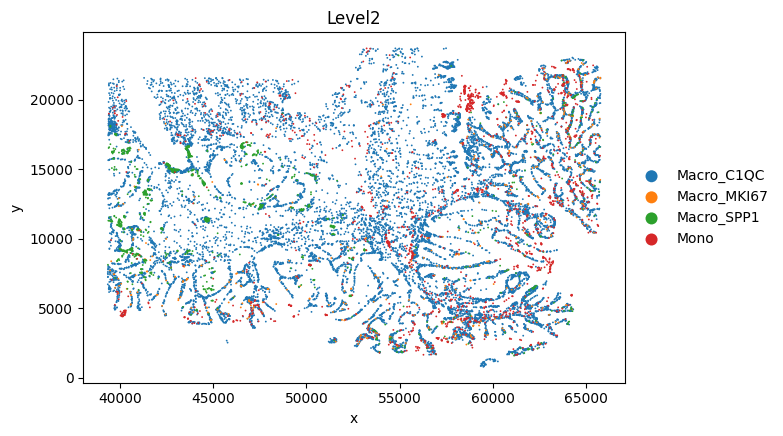

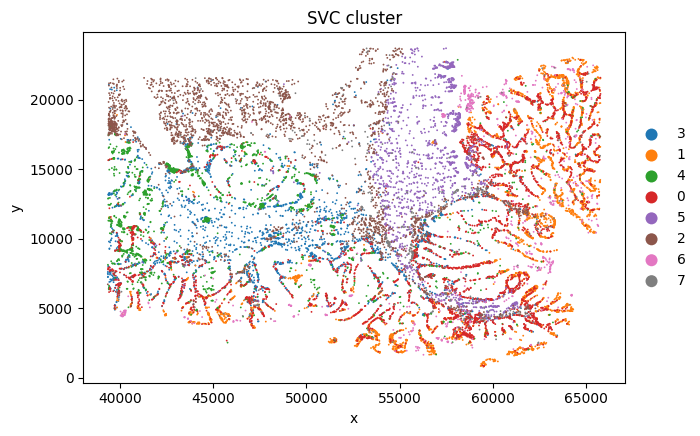

In [5]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors 

size = None
cmap = plt.cm.get_cmap('tab20', lut=10)
palette = [mcolors.to_hex(cmap(i)) for i in range(cmap.N)]

sc.pl.scatter(sc_svc_analysis.sc_SVC_adata_spatial, x="x", y="y",
              color='Level2',
              size=size)
desired_order = ['3','1','4','0','5','2','6','7'] # for better visualization
current_categories = sc_svc_analysis.sc_SVC_adata_spatial.obs['SVC_cluster'].cat.categories.astype(str).tolist()
ordered_categories = [cat for cat in desired_order if cat in current_categories]
ordered_categories += [cat for cat in current_categories if cat not in ordered_categories]
sc_svc_analysis.sc_SVC_adata_spatial.obs['SVC_cluster'] = (
    sc_svc_analysis.sc_SVC_adata_spatial.obs['SVC_cluster'].cat.reorder_categories(ordered_categories, ordered=True)
)
sc.pl.scatter(sc_svc_analysis.sc_SVC_adata_spatial, x="x", y="y",
              color='SVC_cluster',
              size=size)

## Where are the reconstructed TAM states located?

**Method and figure reading.** The maps use the spatial-side object and color the same Xenium coordinates by expert `Level2` annotation or sc-SVC cluster. Separate and side-by-side views are retained for orientation.

**Direct observation.** The reconstructed TAM clusters occupy different, partly overlapping spatial regions in this case. The maps do not themselves quantify co-localization or validate function.

**Interpretation boundary.** The global map is an orientation view. Marker-informed state labels and the rationale for focal follow-up are assigned only after the all-cluster evidence review below.


<Figure size 1000x800 with 0 Axes>

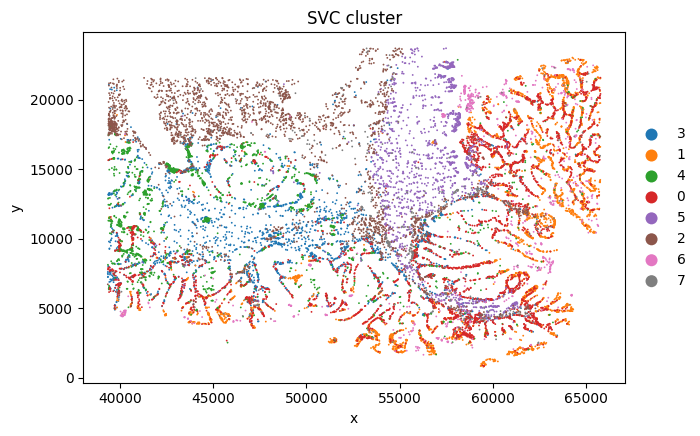

<Figure size 1000x1600 with 0 Axes>

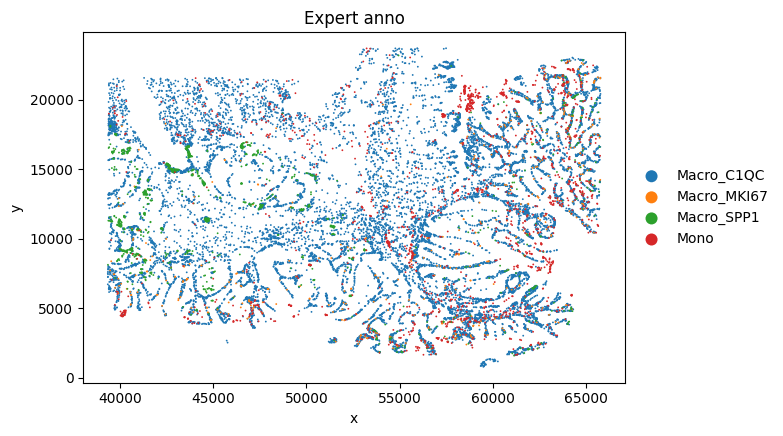

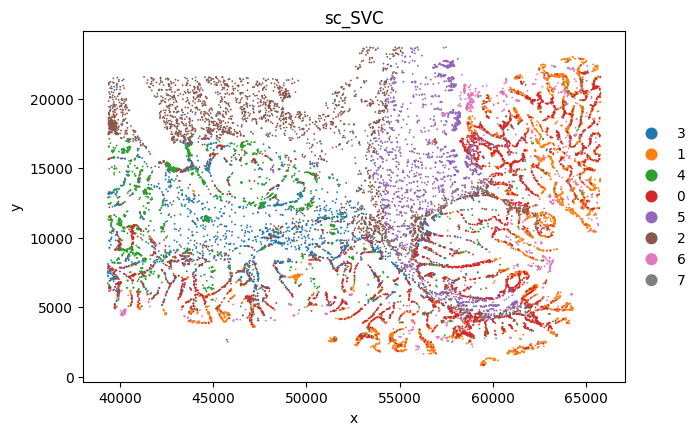

In [6]:
import matplotlib.pyplot as plt
def plot_sc_SVC(adata, color, title = None, file_name = None):

    colors = color if isinstance(color, (list, tuple)) else [color]
    titles = title if isinstance(title, (list, tuple)) else [title] * len(colors)
    plt.figure(figsize=(10, 8*len(colors)))
    for color_key, plot_title in zip(colors, titles):
        sc.pl.scatter(
            adata, x="x", y="y",
            color=color_key,
            title=plot_title, show=False,
        )
    plt.savefig(file_name, dpi = 300)
    plt.show()
    plt.close()

sc_SVC_file_name = f"{output_dir}/sc_SVC.png"
plot_sc_SVC(sc_svc_analysis.sc_SVC_adata_spatial, color='SVC_cluster',
            file_name=sc_SVC_file_name
            )

sc_SVC_file_name = f"{output_dir}/compare.png"
plot_sc_SVC(sc_svc_analysis.sc_SVC_adata_spatial, color=['Level2','SVC_cluster'],
            title=["Expert anno", "sc_SVC"],
            file_name=sc_SVC_file_name
            )

## Evidence collection across all reconstructed TAM clusters

**Question.** Before selecting focal TAM states and a normal comparator, what marker and spatial evidence is present across all eight reconstructed clusters?

**Analysis sequence.** The full differential table is retained as supporting evidence. Curated marker programs are then reviewed for every expression-side cluster, followed immediately by conservative identity annotations and spatial small multiples for every spatial-side cluster. The two H5AD objects share phenotype semantics but contain different, non-observation-paired cells.


In [7]:
all_cluster_nums = [str(i) for i in range(8)]
spatial_cluster = sc_svc_analysis.sc_SVC_adata_spatial.obs['SVC_cluster'].astype(str)
spatial_counts = spatial_cluster.value_counts().reindex(all_cluster_nums, fill_value=0)

## Supporting all-cluster differential table

The full DEG table is retained as supporting evidence before the marker and spatial review below. It is broader than the curated marker panel and does not itself determine focal selection.


In [8]:
sc_svc_analysis.sc_SVC_degs.to_csv(f"{output_dir}/degs_all.csv")
sc_svc_analysis.sc_SVC_degs

,group,gene,logfoldchanges,pvals,pvals_adj,log_q
0,0,MMP12,6.157999,1.990059e-136,2.604589e-132,100.0
1,2,C1QB,2.797948,1.100503e-165,1.440339e-161,100.0
2,6,CTSZ,-3.827421,1.739723e-142,9.487289e-140,100.0
3,6,GPNMB,-4.479141,2.049615e-184,2.235447e-181,100.0
4,6,CD4,-3.998396,1.025761e-164,8.390727e-162,100.0
...,...,...,...,...,...,...
104699,2,SPHK2,-0.000144,9.998170e-01,1.000000e+00,-0.0
104700,2,NSMCE3,-0.000513,9.987000e-01,1.000000e+00,-0.0
104701,2,PRKCQ,-0.001938,9.986947e-01,1.000000e+00,-0.0
104702,2,THOC6,-0.000488,9.986390e-01,1.000000e+00,-0.0


### Marker evidence across all clusters

**Method.** The curated panel is plotted for every expression-side cluster before any focal selection. No markers are recalculated after restricting to focal states.

**How to read the figure.** Dot size and color summarize expression among expression-side cells assigned to each cluster. The plot retains neutral Cluster 0–Cluster 7 labels; the marker-informed identity annotations follow immediately below.


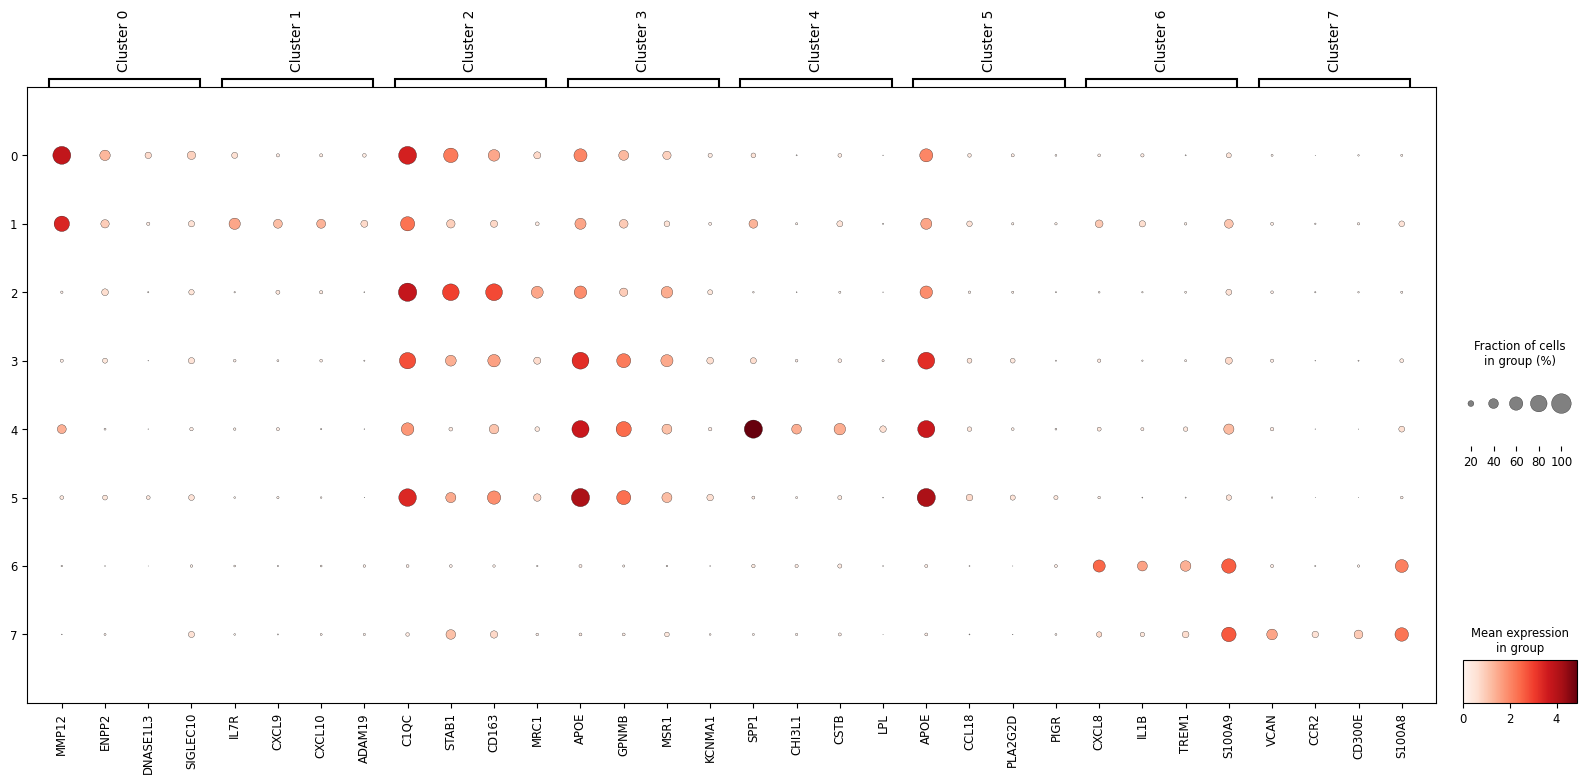

In [9]:
import matplotlib.pyplot as plt

all_cluster_marker_panels = {
    'Cluster 0': ['MMP12', 'ENPP2', 'DNASE1L3', 'SIGLEC10'],
    'Cluster 1': ['IL7R', 'CXCL9', 'CXCL10', 'ADAM19'],
    'Cluster 2': ['C1QC', 'STAB1', 'CD163', 'MRC1'],
    'Cluster 3': ['APOE', 'GPNMB', 'MSR1', 'KCNMA1'],
    'Cluster 4': ['SPP1', 'CHI3L1', 'CSTB', 'LPL'],
    'Cluster 5': ['APOE', 'CCL18', 'PLA2G2D', 'PIGR'],
    'Cluster 6': ['CXCL8', 'IL1B', 'TREM1', 'S100A9'],
    'Cluster 7': ['VCAN', 'CCR2', 'CD300E', 'S100A8'],
}
marker_adata = sc_svc_analysis.sc_SVC_adata_expr[
    sc_svc_analysis.sc_SVC_adata_expr.obs['SVC_cluster'].astype(str).isin(all_cluster_nums)
].copy()
marker_adata.obs['SVC_cluster'] = pd.Categorical(
    marker_adata.obs['SVC_cluster'].astype(str),
    categories=all_cluster_nums,
    ordered=True,
)
sc.pp.normalize_total(marker_adata, target_sum=1e4)
sc.pp.log1p(marker_adata)
marker_dotplot = sc.pl.dotplot(
    marker_adata,
    all_cluster_marker_panels,
    groupby='SVC_cluster',
    categories_order=all_cluster_nums,
    dendrogram=False,
    figsize=(20, 8),
    show=False,
    return_fig=True,
)
marker_dotplot.show()
plt.close('all')

## Marker-informed identity annotations

The displayed marker programs support the conservative functional/state annotations below. They are descriptions of reconstructed marker programs, not independent lineage validation or a cluster-quality ranking.

All-cluster pathway enrichment is not added because unevenly returned terms would not improve the shared marker-based interpretation. The existing focal pathway analysis remains below, after focal selection.


In [10]:
all_cluster_annotations = pd.DataFrame(
    {
        'Cluster': all_cluster_nums,
        'Functional/state annotation': [
            'MMP12+ regulatory macrophage-like',
            'CXCL9/10+ recruiting-inflammatory macrophage-like',
            'C1QC+ resident/homeostatic macrophage-like',
            'APOE/GPNMB+ lipid-handling macrophage-like',
            'SPP1+ matrix-remodeling macrophage-like',
            'CCL18/APOE+ macrophage-like normal comparator',
            'CXCL8/IL1B+ inflammatory monocyte-like',
            'VCAN/CCR2+ classical monocyte-like',
        ],
        'Representative markers': [
            ', '.join(all_cluster_marker_panels[f'Cluster {cluster}'])
            for cluster in all_cluster_nums
        ],
    }
)
all_cluster_annotations.set_index('Cluster')

,Functional/state annotation,Representative markers
Cluster,,
0,MMP12+ regulatory macrophage-like,"MMP12, ENPP2, DNASE1L3, SIGLEC10"
1,CXCL9/10+ recruiting-inflammatory macrophage-like,"IL7R, CXCL9, CXCL10, ADAM19"
2,C1QC+ resident/homeostatic macrophage-like,"C1QC, STAB1, CD163, MRC1"
3,APOE/GPNMB+ lipid-handling macrophage-like,"APOE, GPNMB, MSR1, KCNMA1"
4,SPP1+ matrix-remodeling macrophage-like,"SPP1, CHI3L1, CSTB, LPL"
5,CCL18/APOE+ macrophage-like normal comparator,"APOE, CCL18, PLA2G2D, PIGR"
6,CXCL8/IL1B+ inflammatory monocyte-like,"CXCL8, IL1B, TREM1, S100A9"
7,VCAN/CCR2+ classical monocyte-like,"VCAN, CCR2, CD300E, S100A8"


### Spatial localization across all clusters

**Method and figure reading.** Each panel highlights one spatial-side cluster while all other TAM/monocyte cells remain gray. All panels share the same coordinates, limits, and aspect ratio, so this is a qualitative comparison of localization rather than a region-enrichment statistic.

**Direct observation.** The small multiples provide the spatial evidence for every cluster before focal states and the comparator are selected.


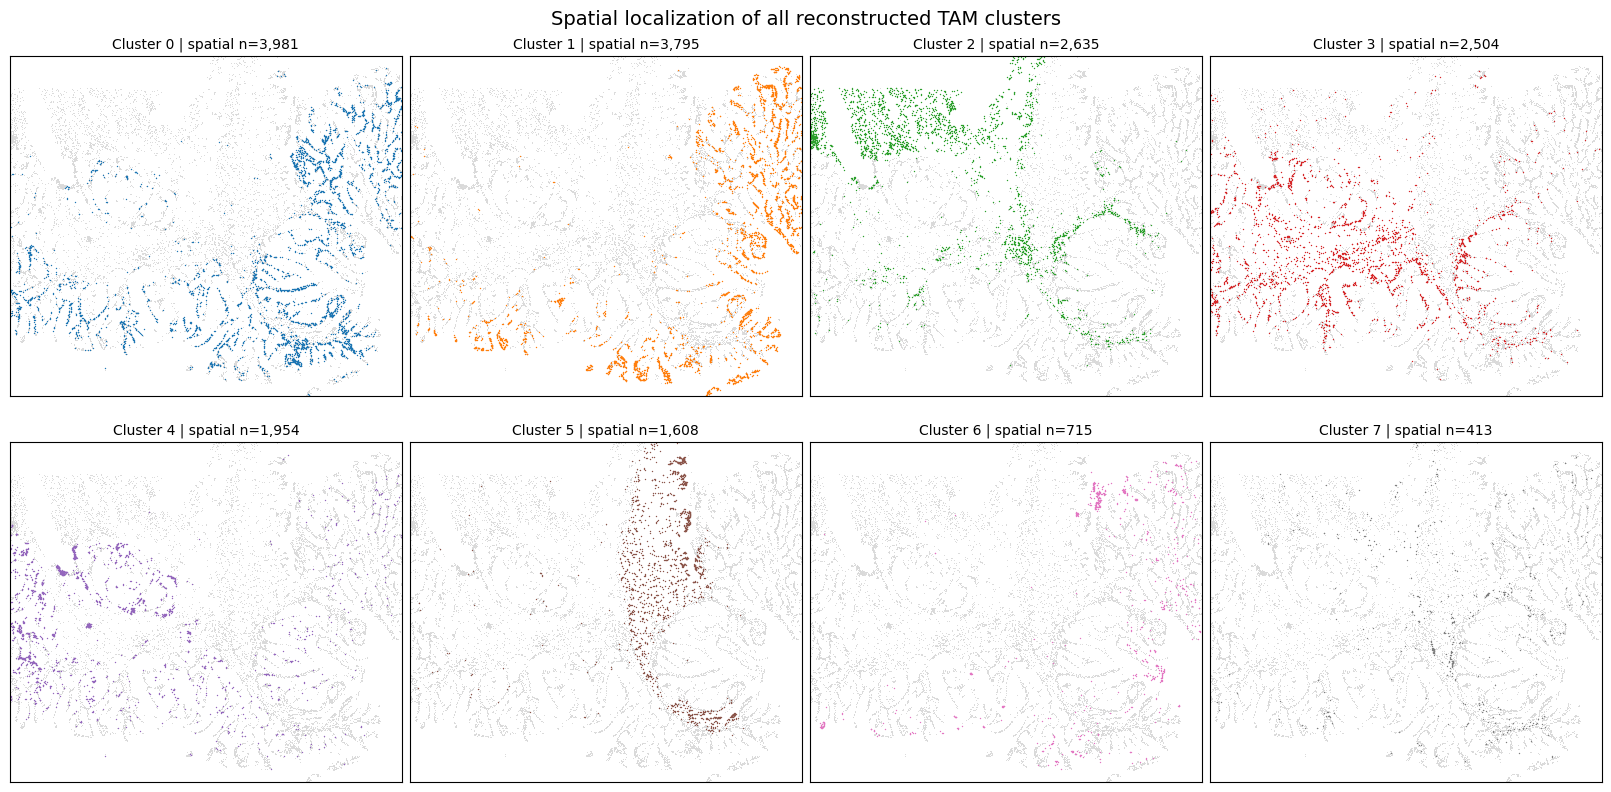

In [11]:
spatial_adata = sc_svc_analysis.sc_SVC_adata_spatial
spatial_x = spatial_adata.obs['x'].to_numpy()
spatial_y = spatial_adata.obs['y'].to_numpy()
spatial_cluster_labels = spatial_adata.obs['SVC_cluster'].astype(str).to_numpy()
spatial_xlim = (spatial_x.min(), spatial_x.max())
spatial_ylim = (spatial_y.min(), spatial_y.max())
cluster_colors = {
    cluster: plt.cm.tab10(index)
    for index, cluster in enumerate(all_cluster_nums)
}

fig, axes = plt.subplots(2, 4, figsize=(16, 8), constrained_layout=True)
for ax, cluster in zip(axes.flat, all_cluster_nums):
    target = spatial_cluster_labels == cluster
    ax.scatter(spatial_x, spatial_y, s=0.45, c='#d9d9d9', linewidths=0, rasterized=True)
    ax.scatter(
        spatial_x[target],
        spatial_y[target],
        s=1.0,
        c=cluster_colors[cluster],
        linewidths=0,
        rasterized=True,
    )
    ax.set_title(f"Cluster {cluster} | spatial n={spatial_counts.loc[cluster]:,}", fontsize=10)
    ax.set_xlim(spatial_xlim)
    ax.set_ylim(spatial_ylim)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle('Spatial localization of all reconstructed TAM clusters', fontsize=14)
plt.show()
plt.close(fig)

## Integrated all-cluster summary and focal selection

**Integrated interpretation.** The table below combines the marker-informed annotations with the spatial review after every cluster has been examined. It retains only the evidence needed to explain the focal selection and the normal comparator.

**Spatial/paper-context labels.** An em dash indicates that no paper-facing context is assigned here. It does not indicate lower quality, absent localization, or absent marker interpretability.


In [12]:
spatial_contexts = {
    '0': 'Regulatory TAM focus / paper TAM_3',
    '1': 'T-cell-recruiting inflammatory focus / paper TAM_1',
    '2': '—',
    '3': '—',
    '4': 'SPP1+ remodeling focus / paper TAM_2',
    '5': 'Normal comparator',
    '6': '—',
    '7': '—',
}
all_cluster_summary = all_cluster_annotations.assign(
    **{'Spatial/paper context': all_cluster_annotations['Cluster'].map(spatial_contexts)}
)
all_cluster_summary

,Cluster,Functional/state annotation,Representative markers,Spatial/paper context
0,0,MMP12+ regulatory macrophage-like,"MMP12, ENPP2, DNASE1L3, SIGLEC10",Regulatory TAM focus / paper TAM_3
1,1,CXCL9/10+ recruiting-inflammatory macrophage-like,"IL7R, CXCL9, CXCL10, ADAM19",T-cell-recruiting inflammatory focus / paper T...
2,2,C1QC+ resident/homeostatic macrophage-like,"C1QC, STAB1, CD163, MRC1",—
3,3,APOE/GPNMB+ lipid-handling macrophage-like,"APOE, GPNMB, MSR1, KCNMA1",—
4,4,SPP1+ matrix-remodeling macrophage-like,"SPP1, CHI3L1, CSTB, LPL",SPP1+ remodeling focus / paper TAM_2
5,5,CCL18/APOE+ macrophage-like normal comparator,"APOE, CCL18, PLA2G2D, PIGR",Normal comparator
6,6,CXCL8/IL1B+ inflammatory monocyte-like,"CXCL8, IL1B, TREM1, S100A9",—
7,7,VCAN/CCR2+ classical monocyte-like,"VCAN, CCR2, CD300E, S100A8",—


### Why clusters 0, 1, and 4 are focal TAM states

The choice is made after the full eight-cluster review, with coverage of non-redundant TAM programs as the primary criterion. Cluster 5 is retained only as the normal comparator, not as a fourth focal TAM state.

| Focal cluster | Integrated cellular/state evidence | Paper-facing context | Follow-up role |
| --- | --- | --- | --- |
| 0 | MMP12+ regulatory macrophage-like: MMP12, ENPP2, DNASE1L3, SIGLEC10 | Regulatory TAM focus | paper TAM_3 |
| 1 | CXCL9/10+ recruiting-inflammatory macrophage-like: IL7R, CXCL9, CXCL10, ADAM19 | T-cell-recruiting inflammatory focus | paper TAM_1 |
| 4 | SPP1+ matrix-remodeling macrophage-like: SPP1, CHI3L1, CSTB, LPL | SPP1+ remodeling focus | paper TAM_2 |

**Scope of the follow-up.** Clusters 0, 1, and 4 were not selected by cluster size, assignment posterior, DEG yield, or apparent interpretability. Cluster 5 is used for the normal comparison. Clusters 2, 3, 6, and 7 received the same marker and spatial review; not being focal does not mean they are lower quality or unidentifiable. The CellPhoneDB block continues to use its predefined TAM subsets for a separate ligand–receptor question; it is not a cluster-quality filter.


In [13]:
# Defined only after the integrated eight-cluster evidence synthesis above.
focal_cluster_nums = ['0', '1', '4']
normal_comparator_cluster = '5'

## Focal follow-up: local pathway enrichment

**Question.** After the all-cluster review and focal selection, which frozen local Hallmark terms summarize the selected regulatory, recruiting-inflammatory, and SPP1+ remodeling TAM programs?

**Figure reading.** Returned terms summarize the current local resource and inputs. A missing term is not evidence of absent pathway activity.


In [14]:
fc_threshold = 1
pathway_num = 20
gene_num = 60
geneset_file = ["./pathway/h.all.v2025.1.Hs.symbols.gmt"]
pathway_file_name = f"{output_dir}/pathway_{fc_threshold}_{pathway_num}.txt"
cluster_nums = focal_cluster_nums
all_pathway = sc_svc_analysis.get_pathway_conclusion(
    cluster_nums, fc_threshold=fc_threshold, pathway_num=pathway_num, gene_num=gene_num, geneset_file=geneset_file, normalize=False)
all_pathway.to_csv(pathway_file_name)
all_pathway

Conducting differential expression analysis...
Cluster 4: 
Up-regulated genes: ['SPP1', 'APOE', 'VIM', 'CHI3L1', 'CD9', 'CSTB', 'FBP1', 'GPNMB', 'FN1', 'APOC1', 'FTL', 'CD52', 'FTH1', 'LSP1', 'S100A6', 'SDC2', 'LGALS1', 'LPL', 'MARCO', 'NUPR1', 'S100A10', 'ANXA2', 'TIMP2', 'ANPEP', 'CTSK', 'APLP2', 'S100A11', 'LGALS3', 'OLR1', 'AQP9', 'CYP27A1', 'SPARC', 'ITGA5', 'GCHFR', 'NCF2', 'RGCC', 'RNASE1', 'FABP5', 'MMP7', 'EMP3', 'APOC2', 'S100A4', 'TSPO', 'CHIT1', 'CD82', 'LIPA', 'PLAUR', 'ITGB3', 'VAT1', 'EMP1', 'ZNF385A', 'COL6A2', 'S100A9', 'GLIPR2', 'SH3BGRL3', 'CD109', 'TREM2', 'FAM20C', 'SLC11A1', 'LTA4H']
Enriched pathways: ['HALLMARK_COAGULATION' 'HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION'
 'HALLMARK_CHOLESTEROL_HOMEOSTASIS' 'HALLMARK_COMPLEMENT'
 'HALLMARK_ANGIOGENESIS' 'HALLMARK_INFLAMMATORY_RESPONSE'
 'HALLMARK_HYPOXIA' 'HALLMARK_APOPTOSIS'
 'HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY' 'HALLMARK_P53_PATHWAY'
 'HALLMARK_KRAS_SIGNALING_UP' 'HALLMARK_XENOBIOTIC_METABOLISM'
 'HALLMARK_U

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes,group
6,h.all.v2025.1.Hs.symbols.gmt,HALLMARK_COAGULATION,10/138,5.445168e-07,0.000014,10.277426,148.235090,LTA4H;APOC1;MMP7;CD9;FN1;ITGB3;SPARC;CTSK;OLR1...,4
8,h.all.v2025.1.Hs.symbols.gmt,HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION,11/200,2.155354e-06,0.000027,7.753806,101.168209,LGALS1;ITGA5;SPP1;FN1;EMP3;ANPEP;ITGB3;COL6A2;...,4
5,h.all.v2025.1.Hs.symbols.gmt,HALLMARK_CHOLESTEROL_HOMEOSTASIS,6/74,7.005318e-05,0.000584,10.813723,103.446837,CD9;LGALS3;PLAUR;S100A11;LPL;FABP5,4
7,h.all.v2025.1.Hs.symbols.gmt,HALLMARK_COMPLEMENT,9/200,1.043317e-04,0.000652,5.968101,54.715163,APOC1;LTA4H;S100A9;LIPA;TIMP2;FN1;LGALS3;PLAUR...,4
1,h.all.v2025.1.Hs.symbols.gmt,HALLMARK_ANGIOGENESIS,4/36,3.764051e-04,0.001882,15.106329,119.111056,LPL;SPP1;OLR1;S100A4,4
...,...,...,...,...,...,...,...,...,...
29,h.all.v2025.1.Hs.symbols.gmt,HALLMARK_UNFOLDED_PROTEIN_RESPONSE,1/113,6.404591e-01,0.706714,1.466147,0.653271,EDEM1,1
1,h.all.v2025.1.Hs.symbols.gmt,HALLMARK_ANDROGEN_RESPONSE,1/101,5.986879e-01,0.706714,1.645862,0.844351,PA2G4,1
18,h.all.v2025.1.Hs.symbols.gmt,HALLMARK_KRAS_SIGNALING_DN,1/200,8.394560e-01,0.839456,0.809784,0.141713,CD80,1
11,h.all.v2025.1.Hs.symbols.gmt,HALLMARK_GLYCOLYSIS,1/200,8.394560e-01,0.839456,0.809784,0.141713,IER3,1


## Which marker programs distinguish the focal TAM states?

**Method and figure reading.** The first dot plot shows automatic top DEGs as supporting evidence. The curated panel emphasizes SPP1/CSTB/CHI3L1 for cluster 4, regulatory/macrophage markers for cluster 0, and IL7R/CXCL9/CXCL10/ADAM19 for cluster 1.

**Direct observation.** The current output separates SPP1-associated, regulatory, and recruiting-inflammatory marker programs across the focal TAM clusters.

**Paper context.** These clusters are described as TAM_2 SPP1+, TAM_3 regulatory, and TAM_1 recruiting-inflammatory. Their proposed ecosystem and clinical roles depend on analyses outside this marker block.


Conducting differential expression analysis...


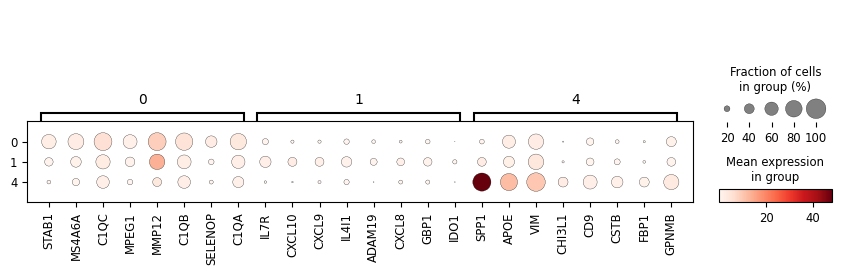

In [15]:
cluster_nums = focal_cluster_nums

degs = sc_svc_analysis.get_svc_degs(cluster_nums, 1)

marker_dict = (
    degs.groupby('group')['gene']
    .apply(lambda x: x.head(8).tolist())
    .to_dict()
)
sc_svc_analysis.get_dot_plot(cluster_nums, marker_dict)

<Figure size 800x600 with 0 Axes>

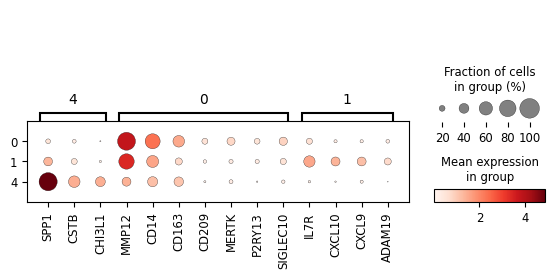

<Figure size 640x480 with 0 Axes>

In [16]:
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.useafm'] = False
plt.figure(figsize=(8, 6))

marker_dict = {
    '4': ['SPP1', 'CSTB', 'CHI3L1'], 
    '0': [
        'MMP12', 
        'CD14',      
        'CD163',     
        'CD209',     
        'MERTK',     
        'P2RY13',    
        'SIGLEC10',  
    ],
    '1': [
        'IL7R', 
        'CXCL10', 
        'CXCL9', 
        'ADAM19' 
    ]
}

sc_svc_analysis.get_dot_plot(cluster_nums, marker_dict, normalize=True)
plt.savefig(f"{output_dir}/sc_SVC_dotplot.pdf", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

## How do TAM spatial-side and expression-side DEG results compare?

**Design.** Two predefined supporting comparisons are run on both SVC objects: cluster 1 Inflammation versus cluster 5, and cluster 0 Regulation versus cluster 5. The two objects share phenotype semantics but contain different observations and gene spaces, so this is not a paired-cell before/after test.

**How to read the outputs.** Each phenotype and side writes its own DEG table, volcano plot, and frozen local enrichment table. The volcano display uses the recorded thresholds in the code cell below; the artifact paths keep the four branches separate.

**Direct observation.** The four retained branches provide distinct spatial-side and expression-side DEG/enrichment results for the two predefined TAM phenotypes.

**Paper context.** The paper uses expanded expression programs and spatial organization to interpret TAM heterogeneity. This supporting comparison does not by itself validate those biological labels or establish method superiority.


Conducting differential expression analysis...


Conducting differential expression analysis...


Conducting differential expression analysis...
Conducting differential expression analysis...


1100

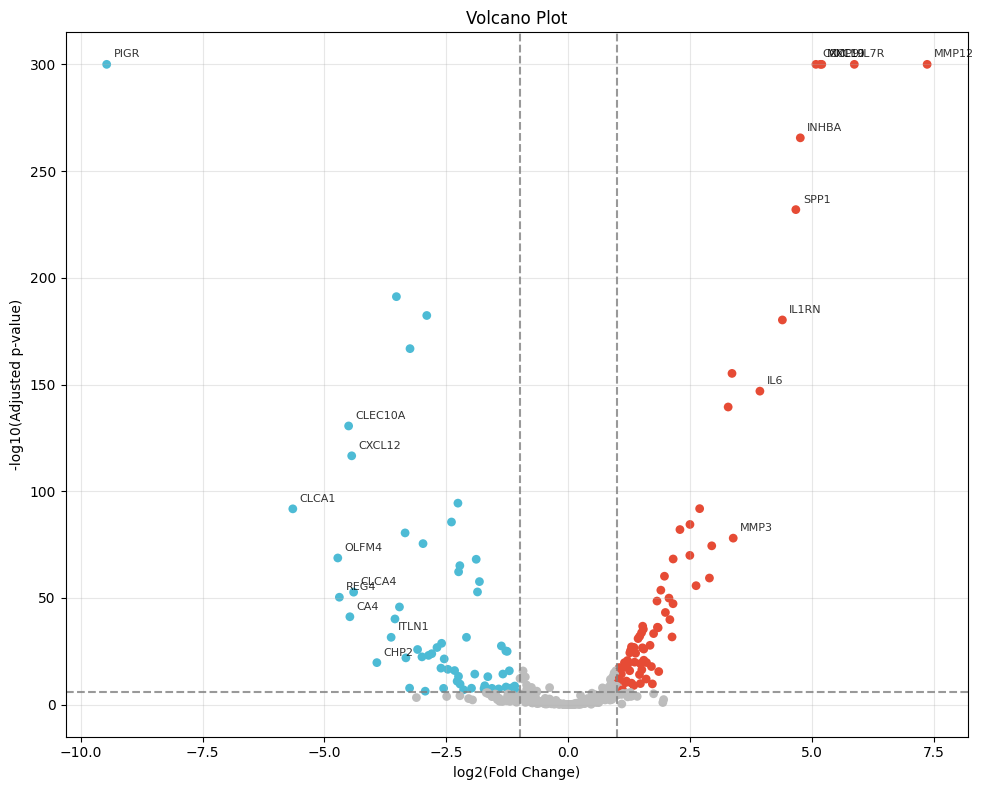

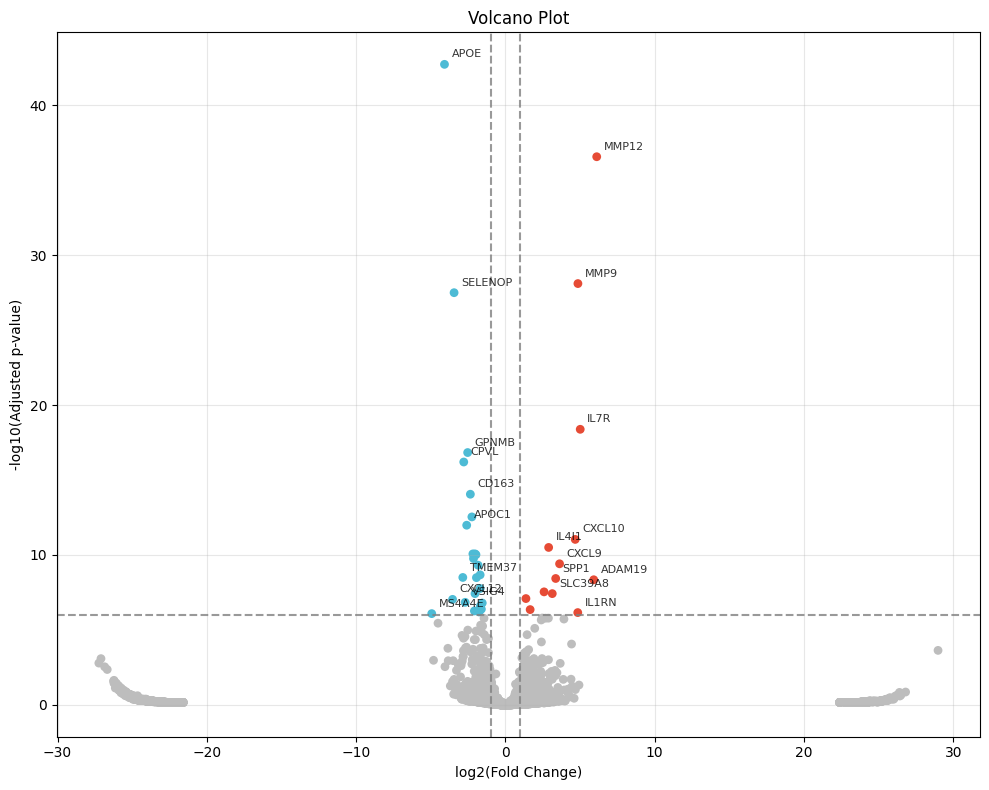

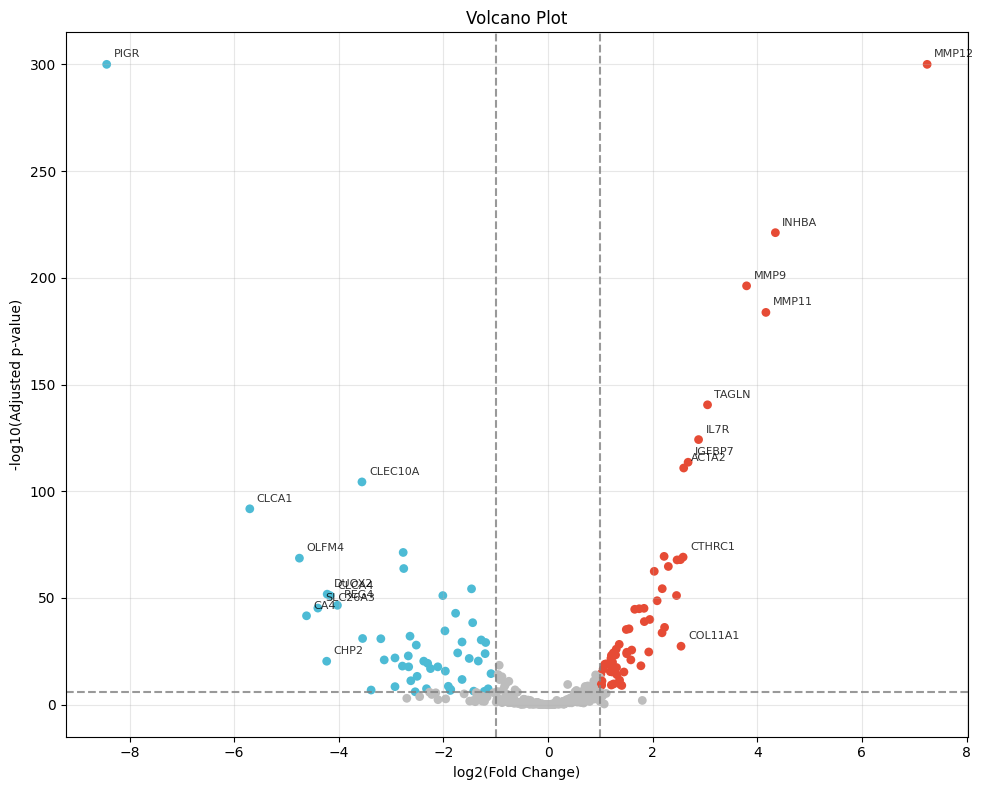

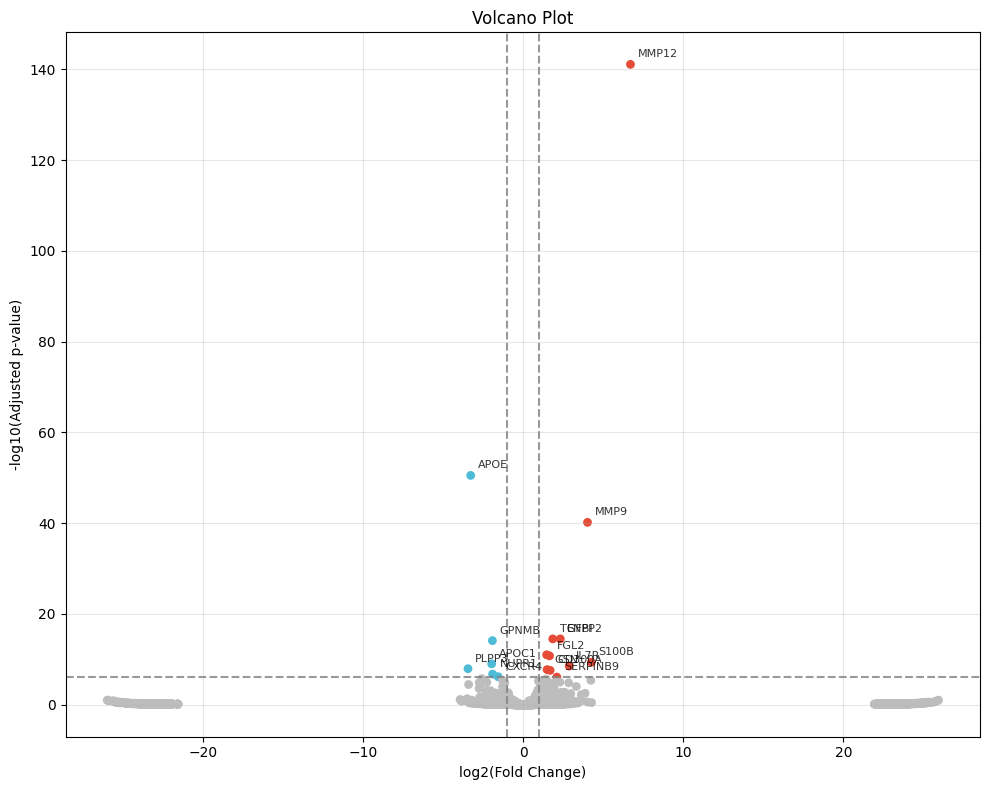

In [17]:
comparison_specs = [("1", "Inflammation"), ("0", "Regulation")]
normal_cluster = normal_comparator_cluster
comparison_datasets = {
    "spatial": sc_svc_analysis.sc_SVC_adata_spatial.copy(),
    "expr": sc_svc_analysis.sc_SVC_adata_expr.copy(),
}

from datetime import datetime, timezone
import hashlib
import json
from pathlib import Path
from revise.analysis.bio import get_degs, get_enrichment, plot_volcano

local_resources = [{
    "id": "hallmark_gmt",
    "path": "reproduce/case/pathway/h.all.v2025.1.Hs.symbols.gmt",
    "sha256": hashlib.sha256(Path(geneset_file[0]).read_bytes()).hexdigest(),
}]
local_enrichment_runs = []
for tumor_cluster_num, phenotype in comparison_specs:
    for dataset_name in ("spatial", "expr"):
        comparison_output_dir = f"{output_dir}/comparisons/{phenotype}/{dataset_name}"
        Path(comparison_output_dir).mkdir(parents=True, exist_ok=True)
        comparison_adata = comparison_datasets[dataset_name]
        comparison_adata = comparison_adata[
            comparison_adata.obs["SVC_cluster"].astype(str).isin(
                [normal_cluster, tumor_cluster_num]
            )
        ].copy()
        comparison_adata.obs["SVC_cluster"] = (
            comparison_adata.obs["SVC_cluster"].astype(str).replace({
                normal_cluster: "Normal-infiltrated",
                tumor_cluster_num: "Tumor-infiltrated",
            })
        )
        degs = get_degs(
            comparison_adata,
            groupby="SVC_cluster",
            method="t-test",
            fc_threshold=None,
        )
        degs = degs[degs["group"] == "Tumor-infiltrated"].reset_index(drop=True)
        degs.to_csv(f"{comparison_output_dir}/degs.csv", index=False)
        plot_volcano(
            degs,
            logfc_threshold=1,
            padj_threshold=1e-6,
            top_k=10,
            save_file_name=f"{comparison_output_dir}/volcano.pdf",
        )
        started_at = datetime.now(timezone.utc).isoformat()
        pathway = get_enrichment(
            degs.loc[degs["logfoldchanges"] > 0, "gene"].head(60).tolist(),
            geneset_file,
            background=None,
        )
        pathway.to_csv(f"{comparison_output_dir}/pathway.csv", index=False)
        local_enrichment_runs.append({
            "phenotype": phenotype,
            "dataset": dataset_name,
            "started_at": started_at,
            "completed_at": datetime.now(timezone.utc).isoformat(),
        })

Path(f"{output_dir}/integration-evidence.json").write_text(
    json.dumps({
        "provider": "GSEApy local enrich",
        "background": None,
        "background_policy": "GSEApy default over local GMT union",
        "resources": local_resources,
        "runs": local_enrichment_runs,
    }, indent=2, sort_keys=True) + "\n",
    encoding="utf-8",
)


## TLS region analysis

In [ ]:
import matplotlib.colors as mcolors
import numpy as np

colors = ["#d3d3d3", "#8b0000"] 
n_bins = 100  # 渐变等级数

cmap = mcolors.LinearSegmentedColormap.from_list("gray_to_darkred", colors, N=n_bins)

def plot_signature(adata, signatures, score_name = "TLS", score_method = "AUCell",size = None, color_map = cmap):
    adata = adata.copy()
    valid_genes = [gene for gene in signatures if gene in adata.var_names]
    print(len(valid_genes), len(signatures))
    
    if score_method == "score_genes":
        sc.tl.score_genes(
                    adata,
                    gene_list=valid_genes,
                    score_name=score_name,
                    use_raw=False,  
                )
    elif score_method == "AUCell":
        import omicverse as ov
        ov.single.geneset_aucell(
                    adata=adata,
                    geneset_name=score_name,
                    geneset=valid_genes,
                    # AUC_threshold = 0.2
                )
        score_name = f"{score_name}_aucell"
   
    sc.pl.scatter(adata, x="x", y="y", 
                    color=score_name, 
                    color_map=color_map,
                    size = size
                    )
    return adata


9 50
ctxcore have been install version: 0.2.0


100%|██████████| 242294/242294 [00:07<00:00, 34458.97it/s]


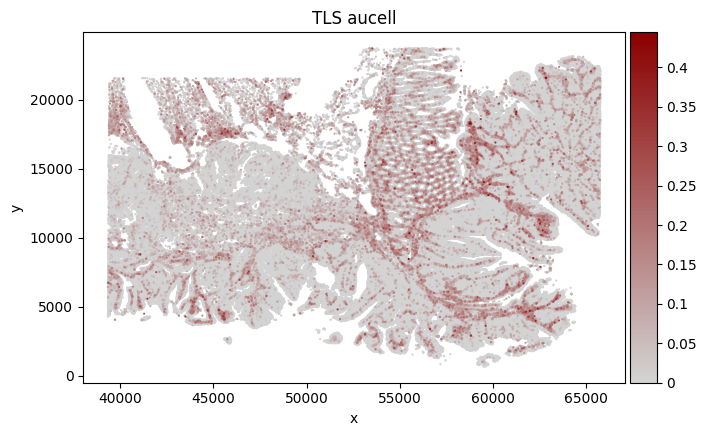

In [ ]:
import scanpy as sc
from pathlib import Path

tls_gene_file = Path("TLS_genes.txt")
TLS_genes = [
    line.strip()
    for line in tls_gene_file.read_text(encoding="utf-8").splitlines()
    if line.strip()
]

size = 10
adata_sp = sc.read("../../raw_data/Real_application/P2CRC_Xenium.h5ad")
adata_sp = adata_sp[adata_sp.obs['transcript_counts']>=60,:]
sc.pp.filter_genes(adata_sp, min_cells=100)

adata_sp = plot_signature(adata_sp, TLS_genes, 
               score_name = "TLS", 
               size = size)

## Spatial distribution of selected immune cell types

The following panels use all filtered Xenium cells as a grey tissue background and highlight T, B, Plasma, or DC cells separately. All panels share the same spatial scale.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from scipy.signal import convolve2d

select_cts = ["T", "B", "Plasma", "DC"]
cell_type_colors = {
    cell_type: plt.cm.tab10(index)
    for index, cell_type in enumerate(select_cts)
}

spatial_x = adata_sp.obs["x"].to_numpy()
spatial_y = adata_sp.obs["y"].to_numpy()
spatial_labels = adata_sp.obs["Level1"].astype(str).to_numpy()
spatial_xlim = (spatial_x.min(), spatial_x.max())
spatial_ylim = (spatial_y.min(), spatial_y.max())
whole_tissue_counts = pd.Series(spatial_labels).value_counts().reindex(select_cts, fill_value=0)
assert (whole_tissue_counts > 0).all()

whole_tissue_summary = whole_tissue_counts.to_frame(name="whole_tissue_n")
whole_tissue_summary.index.name = "cell_type"
display(whole_tissue_summary)


,whole_tissue_n
cell_type,
T,14198
B,309
Plasma,8691
DC,1084


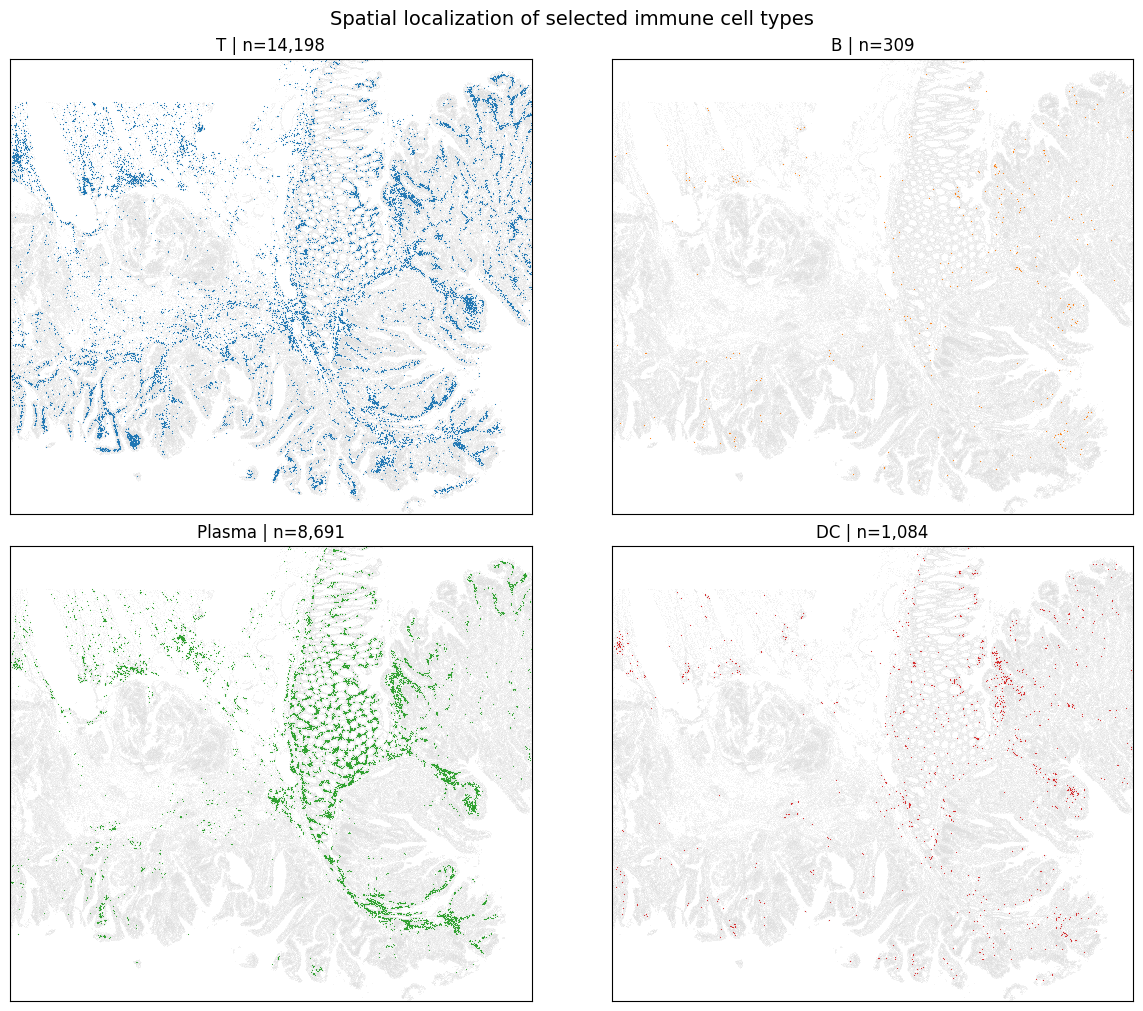

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
for ax, cell_type in zip(axes.flat, select_cts):
    target = spatial_labels == cell_type
    ax.scatter(spatial_x, spatial_y, s=0.08, c="#d9d9d9", linewidths=0, rasterized=True)
    ax.scatter(
        spatial_x[target],
        spatial_y[target],
        s=0.7,
        c=[cell_type_colors[cell_type]],
        linewidths=0,
        rasterized=True,
    )
    ax.set_title(f"{cell_type} | n={whole_tissue_counts.loc[cell_type]:,}")
    ax.set_xlim(spatial_xlim)
    ax.set_ylim(spatial_ylim)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle("Spatial localization of selected immune cell types", fontsize=14)
plt.show()
plt.close(fig)


## Candidate-window co-occurrence benchmark

All candidate windows use the same red-box-scale dimensions and must contain T, B, Plasma, and DC. The selected region maximizes `sum(log1p(local count))`. The raw-score map shows absolute local co-occurrence, while the percentile map shows each window's standing relative to all equal-size valid windows. These are descriptive comparisons, not hypothesis tests or evidence of interaction, recruitment, causality, or TLS biology.


,value
valid candidate windows,6211.000
selected co-occurrence score,22.238
rank among valid windows,1.000
percentile among valid windows,100.000
candidate-score median,15.458
candidate-score 95th percentile,19.989


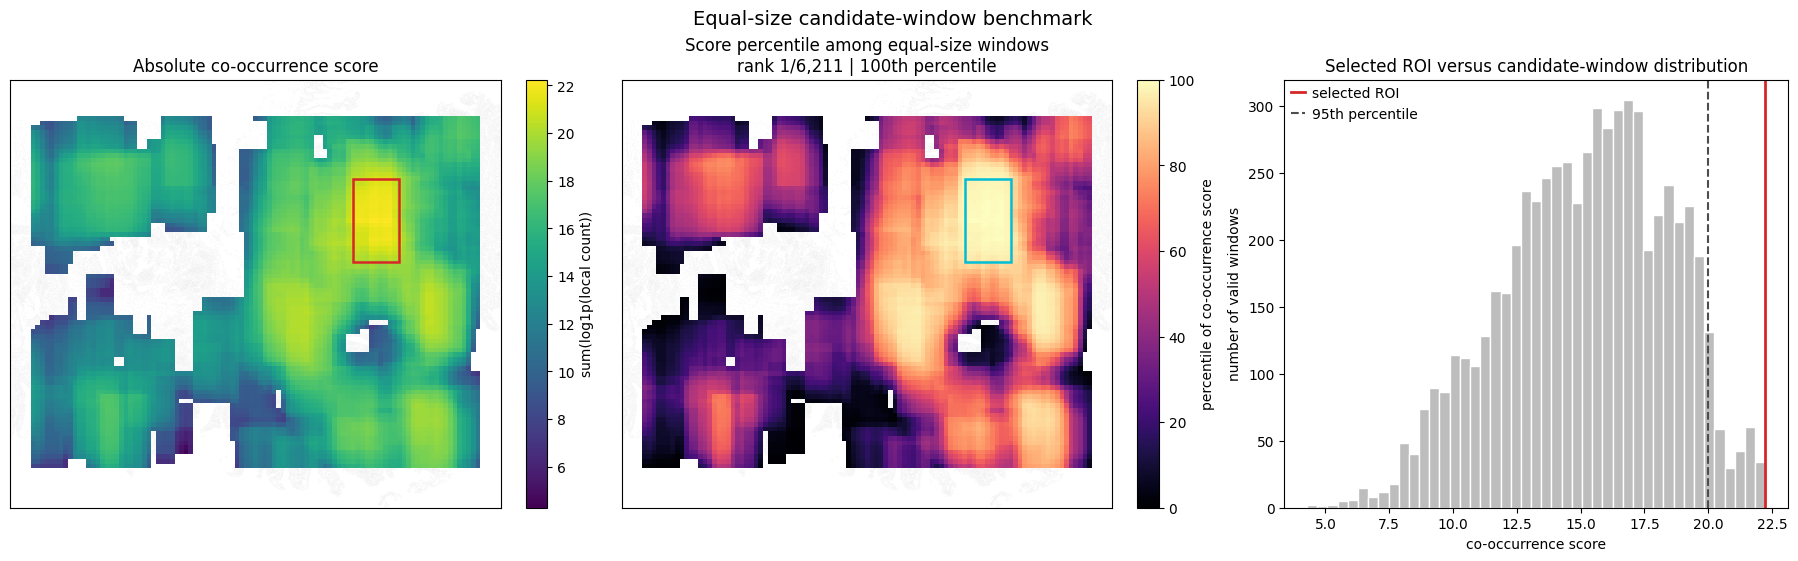

In [ ]:
grid_step = 250.0
roi_width = round((spatial_xlim[1] - spatial_xlim[0]) * 0.09 / grid_step) * grid_step
roi_height = round((spatial_ylim[1] - spatial_ylim[0]) * 0.20 / grid_step) * grid_step
roi_x_bins = int(roi_width / grid_step)
roi_y_bins = int(roi_height / grid_step)

x_edges = np.arange(spatial_xlim[0], spatial_xlim[1] + grid_step, grid_step)
y_edges = np.arange(spatial_ylim[0], spatial_ylim[1] + grid_step, grid_step)
roi_kernel = np.ones((roi_x_bins, roi_y_bins), dtype=int)
candidate_window_counts = []
for cell_type in select_cts:
    target = spatial_labels == cell_type
    cell_type_grid, _, _ = np.histogram2d(
        spatial_x[target], spatial_y[target], bins=(x_edges, y_edges)
    )
    candidate_window_counts.append(convolve2d(cell_type_grid, roi_kernel, mode="valid"))

candidate_window_counts = np.stack(candidate_window_counts)
valid_candidate_windows = (candidate_window_counts > 0).all(axis=0)
assert valid_candidate_windows.any()
candidate_score_grid = np.log1p(candidate_window_counts).sum(axis=0)
scored_candidate_values = candidate_score_grid[valid_candidate_windows]
best_score_grid = np.where(valid_candidate_windows, candidate_score_grid, -np.inf)
best_x_index, best_y_index = np.unravel_index(np.argmax(best_score_grid), best_score_grid.shape)

roi_xlim = (x_edges[best_x_index], x_edges[best_x_index] + roi_width)
roi_ylim = (y_edges[best_y_index], y_edges[best_y_index] + roi_height)
selected_co_occurrence_score = float(candidate_score_grid[best_x_index, best_y_index])
selected_rank = int((scored_candidate_values > selected_co_occurrence_score).sum() + 1)
selected_percentile = float((scored_candidate_values <= selected_co_occurrence_score).mean() * 100)
assert selected_rank == 1

sorted_candidate_scores = np.sort(scored_candidate_values)
candidate_score_percentile_grid = np.full(candidate_score_grid.shape, np.nan)
candidate_score_percentile_grid[valid_candidate_windows] = (
    np.searchsorted(
        sorted_candidate_scores,
        candidate_score_grid[valid_candidate_windows],
        side="right",
    )
    / len(sorted_candidate_scores)
    * 100
)
assert np.isclose(candidate_score_percentile_grid[best_x_index, best_y_index], 100)

candidate_score_summary = pd.DataFrame(
    {
        "value": [
            valid_candidate_windows.sum(),
            selected_co_occurrence_score,
            selected_rank,
            selected_percentile,
            np.median(scored_candidate_values),
            np.quantile(scored_candidate_values, 0.95),
        ]
    },
    index=[
        "valid candidate windows",
        "selected co-occurrence score",
        "rank among valid windows",
        "percentile among valid windows",
        "candidate-score median",
        "candidate-score 95th percentile",
    ],
)
display(candidate_score_summary.style.format({"value": "{:.3f}"}))

candidate_x_centers = x_edges[:candidate_score_grid.shape[0]] + roi_width / 2
candidate_y_centers = y_edges[:candidate_score_grid.shape[1]] + roi_height / 2
candidate_x_plot_edges = np.append(candidate_x_centers - grid_step / 2, candidate_x_centers[-1] + grid_step / 2)
candidate_y_plot_edges = np.append(candidate_y_centers - grid_step / 2, candidate_y_centers[-1] + grid_step / 2)
masked_candidate_scores = np.ma.masked_where(~valid_candidate_windows, candidate_score_grid)
masked_candidate_percentiles = np.ma.masked_invalid(candidate_score_percentile_grid)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), constrained_layout=True)
for ax in axes[:2]:
    ax.scatter(spatial_x, spatial_y, s=0.03, c="#e5e5e5", linewidths=0, rasterized=True)

raw_score_map = axes[0].pcolormesh(
    candidate_x_plot_edges,
    candidate_y_plot_edges,
    masked_candidate_scores.T,
    cmap="viridis",
    shading="flat",
    rasterized=True,
)
axes[0].add_patch(Rectangle((roi_xlim[0], roi_ylim[0]), roi_width, roi_height, fill=False, edgecolor="#d62728", linewidth=1.8))
axes[0].set_title("Absolute co-occurrence score")
fig.colorbar(raw_score_map, ax=axes[0], label="sum(log1p(local count))")

percentile_map = axes[1].pcolormesh(
    candidate_x_plot_edges,
    candidate_y_plot_edges,
    masked_candidate_percentiles.T,
    cmap="magma",
    vmin=0,
    vmax=100,
    shading="flat",
    rasterized=True,
)
axes[1].add_patch(Rectangle((roi_xlim[0], roi_ylim[0]), roi_width, roi_height, fill=False, edgecolor="#00bcd4", linewidth=1.8))
axes[1].set_title(f"Score percentile among equal-size windows\nrank {selected_rank:,}/{len(scored_candidate_values):,} | {selected_percentile:.0f}th percentile")
fig.colorbar(percentile_map, ax=axes[1], label="percentile of co-occurrence score")

score_95th = np.quantile(scored_candidate_values, 0.95)
axes[2].hist(scored_candidate_values, bins=45, color="#bdbdbd", edgecolor="white")
axes[2].axvline(selected_co_occurrence_score, color="#d62728", linewidth=2, label="selected ROI")
axes[2].axvline(score_95th, color="#4d4d4d", linestyle="--", label="95th percentile")
axes[2].set_title("Selected ROI versus candidate-window distribution")
axes[2].set_xlabel("co-occurrence score")
axes[2].set_ylabel("number of valid windows")
axes[2].legend(frameon=False)

for ax in axes[:2]:
    ax.set_xlim(spatial_xlim)
    ax.set_ylim(spatial_ylim)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle("Equal-size candidate-window benchmark", fontsize=14)
plt.show()
plt.close(fig)


## ROI composition and balance compared with candidate windows

The selected ROI is compared with the distribution of all equal-size valid candidate windows. Normalized Shannon entropy is a diagnostic of composition balance, not the criterion used to select the ROI.


,whole_tissue_n,roi_n,roi_fraction_of_type,roi_selected_type_share,log1p_score_contribution
cell_type,,,,,
T,14198,807,5.7%,46.5%,6.695
B,309,43,13.9%,2.5%,3.784
Plasma,8691,706,8.1%,40.7%,6.561
DC,1084,180,16.6%,10.4%,5.198


,selected_roi,candidate_median,candidate_95th_percentile,selected_percentile
co-occurrence score,22.238,15.458,19.989,100.000
normalized Shannon entropy (diagnostic),0.756,0.587,0.714,98.390
T log1p contribution,6.695,5.759,6.458,99.726
B log1p contribution,3.784,1.946,3.178,100.000
Plasma log1p contribution,6.561,4.898,6.675,92.884
DC log1p contribution,5.198,2.996,4.337,100.000


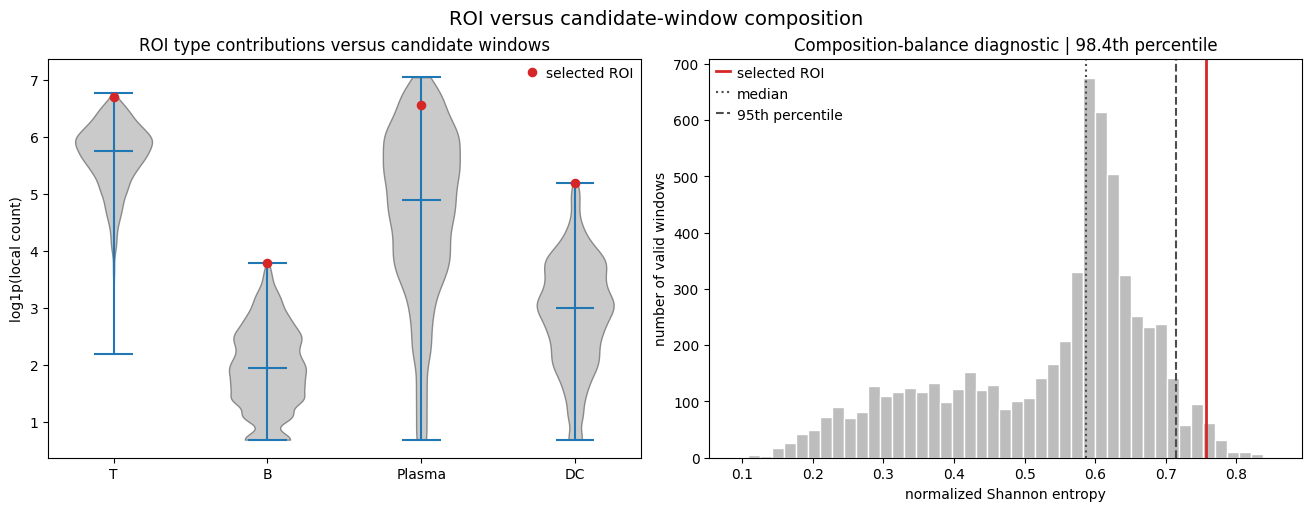

In [ ]:
in_roi = (
    (spatial_x >= roi_xlim[0])
    & (spatial_x <= roi_xlim[1])
    & (spatial_y >= roi_ylim[0])
    & (spatial_y <= roi_ylim[1])
)
roi_counts = pd.Series(spatial_labels[in_roi]).value_counts().reindex(select_cts, fill_value=0)
assert (roi_counts > 0).all()
roi_selected_type_share = roi_counts / roi_counts.sum()
roi_score_contribution = np.log1p(roi_counts)

candidate_selected_total = candidate_window_counts.sum(axis=0)
candidate_type_share = candidate_window_counts / candidate_selected_total[None, :, :]
normalized_shannon_entropy = -(
    candidate_type_share * np.log(np.clip(candidate_type_share, np.finfo(float).tiny, 1.0))
).sum(axis=0) / np.log(len(select_cts))
entropy_values = normalized_shannon_entropy[valid_candidate_windows]
roi_entropy = float(-(
    roi_selected_type_share * np.log(np.clip(roi_selected_type_share, np.finfo(float).tiny, 1.0))
).sum() / np.log(len(select_cts)))
roi_entropy_percentile = float((entropy_values <= roi_entropy).mean() * 100)
assert np.isclose(roi_entropy, normalized_shannon_entropy[best_x_index, best_y_index])

roi_composition_summary = pd.DataFrame(
    {
        "whole_tissue_n": whole_tissue_counts,
        "roi_n": roi_counts,
        "roi_fraction_of_type": roi_counts / whole_tissue_counts,
        "roi_selected_type_share": roi_selected_type_share,
        "log1p_score_contribution": roi_score_contribution,
    }
)
roi_composition_summary.index.name = "cell_type"
display(
    roi_composition_summary.style.format(
        {
            "roi_fraction_of_type": "{:.1%}",
            "roi_selected_type_share": "{:.1%}",
            "log1p_score_contribution": "{:.3f}",
        }
    )
)

candidate_log_contributions = np.log1p(candidate_window_counts[:, valid_candidate_windows])
comparison_rows = [
    ("co-occurrence score", selected_co_occurrence_score, scored_candidate_values),
    ("normalized Shannon entropy (diagnostic)", roi_entropy, entropy_values),
]
comparison_rows.extend(
    (
        f"{cell_type} log1p contribution",
        roi_score_contribution.loc[cell_type],
        candidate_log_contributions[index],
    )
    for index, cell_type in enumerate(select_cts)
)
roi_vs_candidate_summary = pd.DataFrame(
    [
        {
            "selected_roi": roi_value,
            "candidate_median": np.median(candidate_values),
            "candidate_95th_percentile": np.quantile(candidate_values, 0.95),
            "selected_percentile": (candidate_values <= roi_value).mean() * 100,
        }
        for _, roi_value, candidate_values in comparison_rows
    ],
    index=[label for label, _, _ in comparison_rows],
)
display(roi_vs_candidate_summary.style.format("{:.3f}"))

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
violin = axes[0].violinplot(
    candidate_log_contributions.T,
    positions=np.arange(1, len(select_cts) + 1),
    showmedians=True,
)
for body in violin["bodies"]:
    body.set_facecolor("#bdbdbd")
    body.set_edgecolor("#737373")
    body.set_alpha(0.8)
axes[0].scatter(
    np.arange(1, len(select_cts) + 1),
    roi_score_contribution.reindex(select_cts).to_numpy(),
    color="#d62728", s=35, zorder=3, label="selected ROI",
)
axes[0].set_xticks(np.arange(1, len(select_cts) + 1), select_cts)
axes[0].set_ylabel("log1p(local count)")
axes[0].set_title("ROI type contributions versus candidate windows")
axes[0].legend(frameon=False)

entropy_95th = np.quantile(entropy_values, 0.95)
axes[1].hist(entropy_values, bins=45, color="#bdbdbd", edgecolor="white")
axes[1].axvline(roi_entropy, color="#d62728", linewidth=2, label="selected ROI")
axes[1].axvline(np.median(entropy_values), color="#4d4d4d", linestyle=":", label="median")
axes[1].axvline(entropy_95th, color="#4d4d4d", linestyle="--", label="95th percentile")
axes[1].set_title(f"Composition-balance diagnostic | {roi_entropy_percentile:.1f}th percentile")
axes[1].set_xlabel("normalized Shannon entropy")
axes[1].set_ylabel("number of valid windows")
axes[1].legend(frameon=False)

fig.suptitle("ROI versus candidate-window composition", fontsize=14)
plt.show()
plt.close(fig)


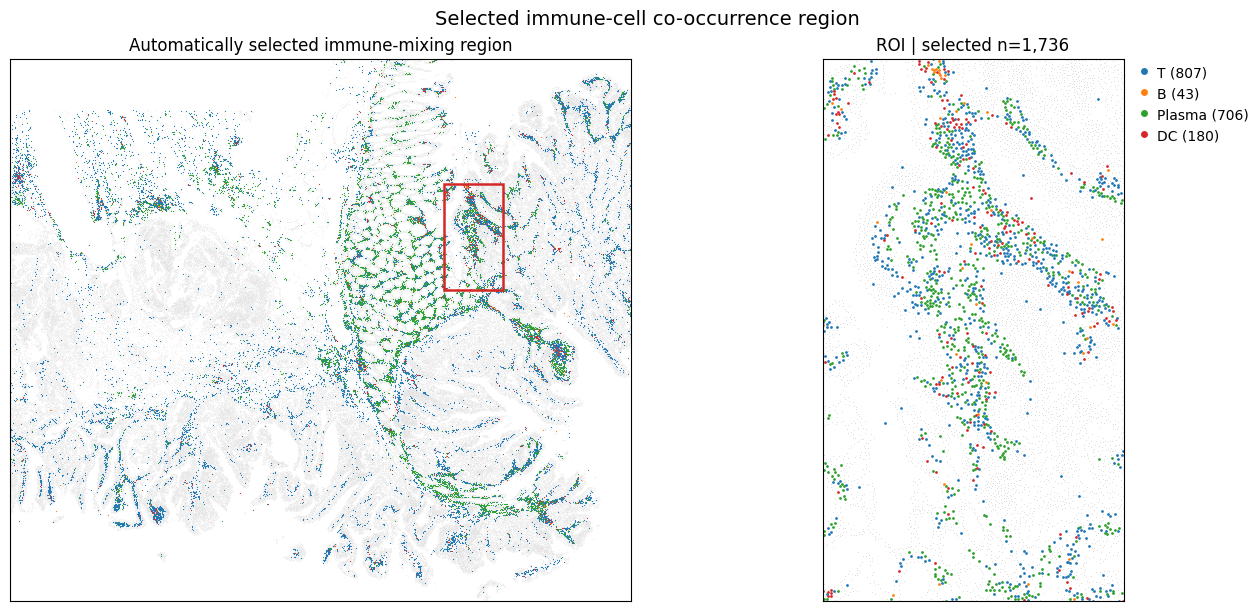

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6), constrained_layout=True)
plot_order = ["Plasma", "T", "DC", "B"]

axes[0].scatter(spatial_x, spatial_y, s=0.08, c="#d9d9d9", linewidths=0, rasterized=True)
for cell_type in plot_order:
    target = spatial_labels == cell_type
    axes[0].scatter(
        spatial_x[target], spatial_y[target], s=0.7,
        c=[cell_type_colors[cell_type]], linewidths=0, rasterized=True,
    )
axes[0].add_patch(
    Rectangle(
        (roi_xlim[0], roi_ylim[0]), roi_width, roi_height,
        fill=False, edgecolor="#d62728", linewidth=1.8,
    )
)
axes[0].set_title("Automatically selected immune-mixing region")
axes[0].set_xlim(spatial_xlim)
axes[0].set_ylim(spatial_ylim)

axes[1].scatter(
    spatial_x[in_roi], spatial_y[in_roi], s=0.4,
    c="#d9d9d9", linewidths=0, rasterized=True,
)
for cell_type in plot_order:
    target = in_roi & (spatial_labels == cell_type)
    axes[1].scatter(
        spatial_x[target], spatial_y[target], s=4,
        c=[cell_type_colors[cell_type]], linewidths=0, rasterized=True,
    )
axes[1].set_title(f"ROI | selected n={roi_counts.sum():,}")
axes[1].set_xlim(roi_xlim)
axes[1].set_ylim(roi_ylim)

legend_handles = [
    Line2D(
        [0], [0], marker="o", color="w", markerfacecolor=cell_type_colors[cell_type],
        markersize=6, label=f"{cell_type} ({roi_counts.loc[cell_type]:,})",
    )
    for cell_type in select_cts
]
axes[1].legend(handles=legend_handles, loc="upper left", bbox_to_anchor=(1.02, 1), frameon=False)

for ax in axes:
    ax.set_aspect("equal", adjustable="box")
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle("Selected immune-cell co-occurrence region", fontsize=14)
plt.show()
plt.close(fig)


## Which preselected ligand–receptor pairs are supported by CellPhoneDB?

**Question and scope.** This block examines five paper-driven, preselected ligand–receptor pairs across the regulatory pair T_5 (paper T_3) / TAM_0 (paper TAM_3) and the recruiting pair T_1 (paper T_0) / TAM_1 (paper TAM_1). It uses T and Mono expression-side cells and **does not use spatial distance**.

**Method.** `run_cellphonedb_v5` executes the recorded CellPhoneDB v5 parameters and returns raw tables. `normalize_cellphonedb_tables` validates and aligns `pvalues`, `significant_means`, and `interaction_scores` on their actual directional cell-pair axis. The intermediate key/count displays are retained as collapsible technical evidence; the normalized five-pair tables and dot plot are the result consumed below.

**Figure reading.** The final dot plot uses `significant_means` for color and CellPhoneDB p-values for point size. Rows are the five preselected pairs; columns are directional source–target group pairs.

**Direct observation.** The retained outputs report directional CellPhoneDB statistics for ANXA1_FPR3, LTB_LTBR, CXCL10_CXCR3, CXCL9_CXCR3, and CCL5_CCR1 in the four predefined groups. This does not establish causal communication, spatial co-localization, or unbiased LR discovery.

**Paper context.** The paper discusses these candidate axes in relation to regulatory and recruiting immune niches, TLS activity, and prognosis. Those spatial and clinical claims rely on additional analyses not reproduced in this CCI block.


In [18]:
output_dir

'/Users/stephen/Documents/wuyushuai_project/wuyushuai_research_project/REVISE/output/notebook_preview/Monocyte/all-clusters-preview-20260820T105443Z/analysis'

In [19]:
import scanpy as sc

T_SVC_adata = sc.read("../../results/sc_SVC_case/P2CRC_Xenium/T/expr.h5ad")
T_SVC_adata = T_SVC_adata[T_SVC_adata.obs['SVC_cluster'].isin(['1','5'])]
# T_SVC_adata = T_SVC_adata[T_SVC_adata.obs['SVC_cluster'].isin(['0','1','5'])]

T_SVC_adata.obs['SVC_cluster'] = [f"T_{i}" for i in T_SVC_adata.obs['SVC_cluster']]

TAM_SVC_adata = sc.read("../../results/sc_SVC_case/P2CRC_Xenium/Mono_Macro/expr.h5ad")
TAM_SVC_adata = TAM_SVC_adata[TAM_SVC_adata.obs['SVC_cluster'].isin(['0','1'])]
TAM_SVC_adata.obs['SVC_cluster'] = [f"TAM_{i}" for i in TAM_SVC_adata.obs['SVC_cluster']]

adata = T_SVC_adata.concatenate(TAM_SVC_adata)
adata

AnnData object with n_obs × n_vars = 1686 × 13088
    obs: 'Level1', 'Level2', 'SVC_cluster', 'max_score', 'batch'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    obsm: 'SVC_cluster'

In [20]:
adata.obs['SVC_cluster'].value_counts()

SVC_cluster
T_5      857
TAM_0    361
T_1      287
TAM_1    181
Name: count, dtype: int64

In [21]:
celltype_key = "SVC_cluster"
from pathlib import Path
from revise.analysis.advanced.cell_communication import run_cellphonedb_v5
cpdb_path = Path('./CCI/cellphonedb.zip')
cpdb_results, adata_cpdb = run_cellphonedb_v5(
    adata,
    database_path=cpdb_path,
    celltype_key=celltype_key,
    min_cell_fraction=0.005,             
    min_genes=200,                       
    min_cells=3,                         
    iterations=1000,                     
    threshold=0.1,                       
    pvalue=0.05,                         
    threads=10,                          
    output_dir=f'{output_dir}/cpdb_results',         
    cleanup_temp=True                    
)

🔬 Starting CellPhoneDB analysis...
✅ Valid CellPhoneDB database found: CCI/cellphonedb.zip (0.1 MB)
   - Original data: 1686 cells, 13088 genes
   - Cell types passing 0.5% threshold: 4
   - Minimum cells required: 8
   - After filtering: 1686 cells, 13088 genes
   - After preprocessing: 1686 cells, 12249 genes
   - Temporary directory: /var/folders/fd/3dt4wzz12bx4ycmm4k_gp_km0000gn/T/cpdb_temp_t9hpj4ce
   - Output directory: /Users/stephen/Documents/wuyushuai_project/wuyushuai_research_project/REVISE/output/notebook_preview/Monocyte/all-clusters-preview-20260820T105443Z/analysis/cpdb_results


   - Created temporary input files
   - Running CellPhoneDB statistical analysis...
Reading user files...


The following user files were loaded successfully:
/var/folders/fd/3dt4wzz12bx4ycmm4k_gp_km0000gn/T/cpdb_temp_t9hpj4ce/counts_matrix.h5ad
/var/folders/fd/3dt4wzz12bx4ycmm4k_gp_km0000gn/T/cpdb_temp_t9hpj4ce/metadata.tsv
[ ][CORE][20/08/26-18:55:08][INFO] [Cluster Statistical Analysis] Threshold:0.1 Iterations:1000 Debug-seed:42 Threads:10 Precision:3


[ ][CORE][20/08/26-18:55:08][WARNING] Debug random seed enabled. Set to 42


[ ][CORE][20/08/26-18:55:09][INFO] Running Real Analysis


...

[ ][CORE][20/08/26-18:55:15][INFO] Scoring interactions: Filtering genes per cell type..


[ ][CORE][20/08/26-18:55:15][INFO] Scoring interactions: Calculating mean expression of each gene per group/cell type..


[ ][CORE][20/08/26-18:55:16][INFO] Scoring interactions: Calculating scores for all interactions and cell types..


/Users/stephen/miniconda3/envs/python3.10/lib/python3.10/site-packages/torch/cuda/__init__.py:58: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/Users/stephen/miniconda3/envs/python3.10/lib/python3.10/site-packages/torch/cuda/__init__.py:58: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/Users/stephen/miniconda3/envs/python3.10/lib/python3.10/site-packages/torch/cuda/__init__.py:58: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for y

Saved deconvoluted to /Users/stephen/Documents/wuyushuai_project/wuyushuai_research_project/REVISE/output/notebook_preview/Monocyte/all-clusters-preview-20260820T105443Z/analysis/cpdb_results/statistical_analysis_deconvoluted_08_20_2026_185518.txt
Saved deconvoluted_percents to /Users/stephen/Documents/wuyushuai_project/wuyushuai_research_project/REVISE/output/notebook_preview/Monocyte/all-clusters-preview-20260820T105443Z/analysis/cpdb_results/statistical_analysis_deconvoluted_percents_08_20_2026_185518.txt
Saved means to /Users/stephen/Documents/wuyushuai_project/wuyushuai_research_project/REVISE/output/notebook_preview/Monocyte/all-clusters-preview-20260820T105443Z/analysis/cpdb_results/statistical_analysis_means_08_20_2026_185518.txt
Saved pvalues to /Users/stephen/Documents/wuyushuai_project/wuyushuai_research_project/REVISE/output/notebook_preview/Monocyte/all-clusters-preview-20260820T105443Z/analysis/cpdb_results/statistical_analysis_pvalues_08_20_2026_185518.txt
Saved signific

In [22]:
cpdb_results.keys()

dict_keys(['deconvoluted', 'deconvoluted_percents', 'means', 'pvalues', 'significant_means', 'CellSign_active_interactions', 'CellSign_active_interactions_deconvoluted', 'interaction_scores'])

In [23]:
select_clusters = ['T_5','TAM_0']
df = cpdb_results['significant_means']
df = cpdb_results['interaction_scores']
df
# df = df[(df['source'].isin(select_clusters)) & (df['target'].isin(select_clusters))]
# df_sorted = df.sort_values('mean', ascending=False)
# df_sorted

,id_cp_interaction,interacting_pair,partner_a,partner_b,gene_a,gene_b,secreted,receptor_a,receptor_b,annotation_strategy,...,TAM_1|T_1,TAM_1|T_5,T_1|TAM_0,T_1|TAM_1,T_1|T_1,T_1|T_5,T_5|TAM_0,T_5|TAM_1,T_5|T_1,T_5|T_5
0,CPI-SC0A2DB962D,CDH1_integrin_a2b1_complex,simple:P12830,complex:integrin_a2b1_complex,CDH1,NaN,False,False,False,curated,...,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.000,0.0,0.0
2,CPI-SC0C8B7BCBB,COL11A1_integrin_a2b1_complex,simple:P12107,complex:integrin_a2b1_complex,COL11A1,NaN,True,False,False,curated,...,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.000,0.0,0.0
4,CPI-SC0B86B7CED,COL12A1_integrin_a2b1_complex,simple:Q99715,complex:integrin_a2b1_complex,COL12A1,NaN,True,False,False,curated,...,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.000,0.0,0.0
6,CPI-SC0CCCF9A7F,COL14A1_integrin_a2b1_complex,simple:Q05707,complex:integrin_a2b1_complex,COL14A1,NaN,True,False,False,curated,...,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.000,0.0,0.0
7,CPI-SC0E85E1FB0,COL15A1_integrin_a2b1_complex,simple:P39059,complex:integrin_a2b1_complex,COL15A1,NaN,True,False,False,curated,...,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2899,CPI-SS0822AEF5F,PTPRC_MRC1,simple:P08575,simple:P22897,PTPRC,MRC1,False,False,True,curated,...,0.0,0.0,100.0,40.149,0.0,0.0,35.727,14.344,0.0,0.0
2900,CPI-SS096F8C268,PTPRD_IL1RAP,simple:P23468,simple:Q9NPH3,PTPRD,IL1RAP,True,True,True,curated,...,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.000,0.0,0.0
2905,CPI-SS016FD0C8A,RNASET2_TLR8,simple:O00584,simple:Q9NR97,RNASET2,TLR8,True,False,True,curated,...,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.000,0.0,0.0
2907,CPI-SS02A170A99,SPN_SIGLEC1,simple:P16150,simple:Q9BZZ2,SPN,SIGLEC1,True,False,False,curated,...,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.000,0.0,0.0


In [24]:
cpdb_results.keys()
deconvoluted_percents = cpdb_results['deconvoluted_percents']

In [25]:
select_LR_pairs = [
    'ANXA1_FPR3','LTB_LTBR',
    'CXCL10_CXCR3','CXCL9_CXCR3', 
    'CCL5_CCR1',
]

In [26]:
from revise.analysis.advanced.cell_communication import normalize_cellphonedb_tables

cell_groups = ["T_1", "T_5", "TAM_0", "TAM_1"]
if set(adata.obs['SVC_cluster'].astype(str).unique()) != set(cell_groups):
    raise ValueError("CellPhoneDB input groups do not match the four-group contract")
print(cell_groups)

cpdb_tables = normalize_cellphonedb_tables(cpdb_results, cell_groups)
pvals = cpdb_tables['pvalues'].loc[select_LR_pairs]

# significant_means
significant_means = cpdb_tables['significant_means'].loc[select_LR_pairs]

interaction_scores = cpdb_tables['interaction_scores'].loc[select_LR_pairs]

interaction_scores
from pathlib import Path
cpdb_checkpoint_dir = Path(output_dir) / "cellphonedb"
cpdb_checkpoint_dir.mkdir(parents=True, exist_ok=True)
for table_name, table in cpdb_results.items():
    if table_name in ("pvalues", "significant_means", "interaction_scores"):
        table.to_csv(cpdb_checkpoint_dir / f"{table_name}.csv", index=False)
normalized_selected_lr = pvals.reset_index()[["LR_pair"]].rename(columns={"LR_pair": "pair"})
normalized_selected_lr[["gene_a", "gene_b"]] = normalized_selected_lr["pair"].str.split("_", n=1, expand=True)
normalized_selected_lr[["gene_a", "gene_b", "pair"]].to_csv(
    cpdb_checkpoint_dir / "normalized_selected_lr.csv", index=False
)
for selected_table in (pvals, significant_means, interaction_scores):
    selected_table.index.name = "pair"
    selected_table.columns.name = "cell_pair"
selected_lr_consumption = pd.concat({
    "pvalue": pvals.stack(dropna=False),
    "significant_mean": significant_means.stack(dropna=False),
    "interaction_score": interaction_scores.stack(dropna=False),
}, axis=1).reset_index()
selected_lr_consumption.to_csv(
    cpdb_checkpoint_dir / "selected_lr_consumption.csv", index=False
)
import hashlib
import importlib.metadata
import json
(cpdb_checkpoint_dir / "evidence.json").write_text(
    json.dumps({
        "provider": "CellPhoneDB",
        "provider_version": importlib.metadata.version("cellphonedb"),
        "database": {
            "path": "reproduce/case/CCI/cellphonedb.zip",
            "sha256": hashlib.sha256(cpdb_path.read_bytes()).hexdigest(),
        },
        "celltype_key": celltype_key,
        "cell_groups": cell_groups,
        "parameters": {
            "min_cell_fraction": 0.005,
            "min_genes": 200,
            "min_cells": 3,
            "iterations": 1000,
            "threshold": 0.1,
            "pvalue": 0.05,
            "threads": 10,
            "cleanup_temp": True,
        },
        "selected_lr_pairs": select_LR_pairs,
        "raw_tables": ["pvalues", "significant_means", "interaction_scores"],
        "normalized_checkpoint": "cellphonedb/normalized_selected_lr.csv",
        "consumption_checkpoint": "cellphonedb/selected_lr_consumption.csv",
    }, indent=2, sort_keys=True) + "\n",
    encoding="utf-8",
)


['T_1', 'T_5', 'TAM_0', 'TAM_1']


873

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams['pdf.fonttype'] = 42      
mpl.rcParams['ps.useafm'] = False     
def LR_pair_dotplot(scores, pvals, cmap='RdBu_r', pval_cutoff=0.1, save_file_name=None):
    
    row_names = scores.index.tolist()
    col_names = scores.columns.tolist()
    scores = np.array(scores)
    pvals = np.array(pvals)
    
    score_min = np.nanmin(scores)
    score_max = np.nanmax(scores)
    
    log_pvals = -np.log10(pvals + 1e-20)  
    
    size_mask = pvals >= pval_cutoff
    log_pvals_filtered = log_pvals.copy()
    log_pvals_filtered[size_mask] = 0  
    
    min_size = 20
    max_size = 200
    
    significant_log_pvals = log_pvals_filtered[log_pvals_filtered > 0]
    if len(significant_log_pvals) > 0:
        min_sig_pval = np.min(significant_log_pvals)
        max_sig_pval = np.max(significant_log_pvals)
    else:
        min_sig_pval = 1  
        max_sig_pval = 3  
    
    sizes = np.zeros_like(log_pvals_filtered)
    significant_mask = log_pvals_filtered > 0
    sizes[significant_mask] = np.interp(
        log_pvals_filtered[significant_mask], 
        (min_sig_pval, max_sig_pval), 
        (min_size, max_size)
    )
    
    fig, ax = plt.subplots(figsize=(10,4))
    
    # Plot each point (with the y-axis inverted)
    for i in range(scores.shape[0]):
        for j in range(scores.shape[1]):
            if not np.isnan(scores[i, j]) and not np.isnan(pvals[i, j]):
                if sizes[i, j] > 0:  

                    ax.scatter(j, len(row_names)-1-i, 
                              c=[scores[i, j]], 
                              s=sizes[i, j], 
                              cmap=cmap, 
                              alpha=0.7,
                              edgecolors='black', 
                              linewidth=0.5,
                              vmin=score_min, 
                              vmax=score_max)
    
    ax.set_xticks(range(len(col_names)))
    ax.set_xticklabels(col_names, rotation=45, ha='right', fontsize=10)
    
    ax.set_yticks(range(len(row_names)))
    ax.set_yticklabels(row_names[::-1], fontsize=10)
    ax.set_xlim(-0.5, len(col_names)-0.5)
    ax.set_ylim(-0.5, len(row_names)-0.5)
    
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax.set_axisbelow(True)
    
    norm = mcolors.Normalize(vmin=score_min, vmax=score_max)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, shrink=0.5, aspect=20, pad=0.02)
    cbar.set_label('Scores', rotation=270, labelpad=15)
    
    if len(significant_log_pvals) > 0:
        use_power_scale = (max_sig_pval / min_sig_pval > 100) and (max_sig_pval > 10)
        
        if use_power_scale:
            min_power = 0  
            max_power = np.ceil(np.log10(max_sig_pval))  
            
            representative_log_pvals = [10**power for power in range(int(min_power), int(max_power)+1)]
            
            representative_log_pvals = [x for x in representative_log_pvals 
                                      if x <= max_sig_pval * 1.1]  
        else:
            num_points = min(5, max(2, int(max_sig_pval - min_sig_pval) + 1))
            representative_log_pvals = np.linspace(min_sig_pval, max_sig_pval, num_points)
        
        representative_log_pvals = [x for x in representative_log_pvals 
                                   if min_sig_pval <= x <= max_sig_pval * 1.1]
        
        representative_log_pvals = sorted(set(representative_log_pvals))
        
        if not representative_log_pvals:
            representative_log_pvals = [min_sig_pval, max_sig_pval]
        
        representative_sizes = np.interp(representative_log_pvals, 
                                       (min_sig_pval, max_sig_pval), 
                                       (min_size, max_size))
        
        legend_elements = []
        for log_pval, size in zip(representative_log_pvals, representative_sizes):
            if log_pval >= 100 or (log_pval >= 1 and log_pval == int(log_pval)):
                label = f'-log10(p) = {log_pval:.0f}'
            elif log_pval >= 10:
                label = f'-log10(p) = {log_pval:.1f}'
            else:
                label = f'-log10(p) = {log_pval:.2f}'
            
            legend_elements.append(Line2D([0], [0], 
                                        marker='o', 
                                        color='w', 
                                        markerfacecolor='gray',
                                        markersize=np.sqrt(size)/2,
                                        markeredgecolor='black',
                                        label=label))
    else:
        legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
                                markersize=0, label='No significant points')]
    
    significance_legend = ax.legend(handles=legend_elements, 
                                  loc='upper left', 
                                  bbox_to_anchor=(1.02, 1.0),
                                  title='Significance',
                                  frameon=True,
                                  fancybox=True,
                                  shadow=True,
                                  fontsize=9)
    
    ax.set_xlabel('Cell pairs', fontsize=12)
    ax.set_ylabel('LR pairs', fontsize=12)
    ax.set_title(f'LR Pair Dot Plot', fontsize=14, pad=20)
    
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    
    if save_file_name:
        plt.savefig(save_file_name, dpi=300, bbox_inches='tight')
    else:
        plt.show()

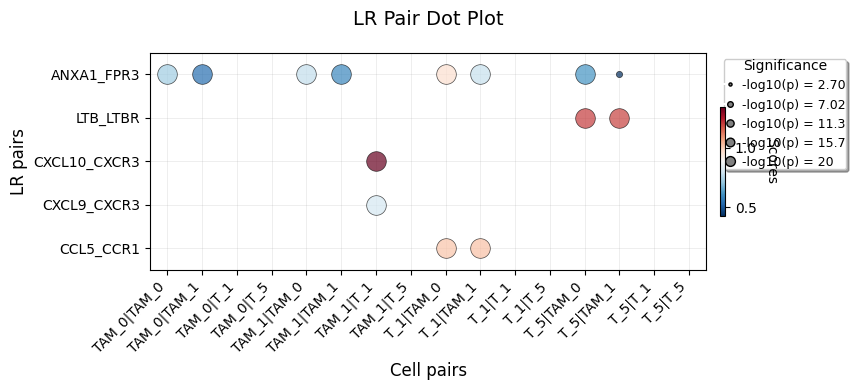

In [28]:
scores = interaction_scores.copy()
scores = significant_means.copy()

save_file_name = None
save_file_name = f"{output_dir}/LR_pair_dotplot.pdf"
LR_pair_dotplot(scores, pvals, save_file_name = save_file_name)
